# Data analysis

### Imports

In [2]:
# Adding autoimport
# This cell will automatically reload modules before executing each code cell.
# This is helpful so you don't need to restart the Jupyter kernel after changing your custom modules.
%load_ext autoreload
%autoreload 2


In [3]:
import pickle
import pandas as pd
from tqdm import tqdm
from mps_utils import to_comp_basis
from nash_utils import plot_state, compute_exploitability, plot_exploitability_vs_angle, compute_and_validate_nash_equilibrium
from game import get_default_H
import numpy as np
import os

Using CPU


### Setup

4-player games; Retrieval of dataframe of Converged Equilibrium data

In [4]:
H = get_default_H(num_players=4)

In [5]:
test_csv_path = "data/cached/opt_fid_state_chi1_lr1e-02_steps1000_alpha5e-02_methodunitary_20251202_124512.csv"
test_pkl_path = "data/cached/opt_fid_state_chi1_lr1e-02_steps1000_alpha5e-02_methodunitary_20251202_124512.pkl"
data = pickle.load(open(test_pkl_path, 'rb'))

In [6]:
data_dir = "data/cached"
df = []
for filename in tqdm(os.listdir(data_dir)):
    if filename.endswith('.pkl'):
        data = pickle.load(open(os.path.join(data_dir, filename), 'rb'))[-1]
        df.append(data)

df = pd.DataFrame(df)
print(df.iloc[1].keys())

100%|██████████| 94/94 [00:00<00:00, 185.54it/s]

Index(['energy', 'welfare', 'state', 'ent_params'], dtype='object')


## Optimal Fiducial States for 4 players

We're happy with a $\epsilon$-approximate Nash Equilibrium with $\epsilon=0.01$, meaning that if none of the players has exploitability more than $\epsilon$ then is qualified as an NE. The fluctuations of the welfare can be attributed to this numerical tolerance.

                                              energy    welfare  \
0  [4.55943415495084, 3.332650696422151, 4.753729...  12.645815   
1  [2.312619574014647, 2.7745852299541083, 2.3126...  10.174518   
2  [2.1355628452759765, 2.9380176723550493, 2.135...  10.146649   
3  [2.2217034365594013, 2.8463098310920856, 2.221...  10.136864   
4  [2.1894999783430786, 2.875230953404325, 2.1894...  10.129538   
5  [2.3417924325129906, 2.71762652715164, 2.34483...  10.120985   
6  [2.9427686606103203, 2.1111474752598323, 2.938...  10.105396   
7  [2.7502854578916365, 2.2887732986876377, 2.750...  10.078097   
8  [2.7539841958422766, 2.2797862028536566, 2.753...  10.067564   
9  [2.706696053254552, 2.3262983579310323, 2.7068...  10.066010   

                                               state  \
0  [[[[-0.18332884+0.52236086j -0.18699708-0.0652...   
1  [[[[-0.7699565 -0.06869619j -0.02097272-0.0178...   
2  [[[[-0.69707764-0.02592854j  0.20008754+0.3036...   
3  [[[[-0.68892861+0.01000803j  0.3654

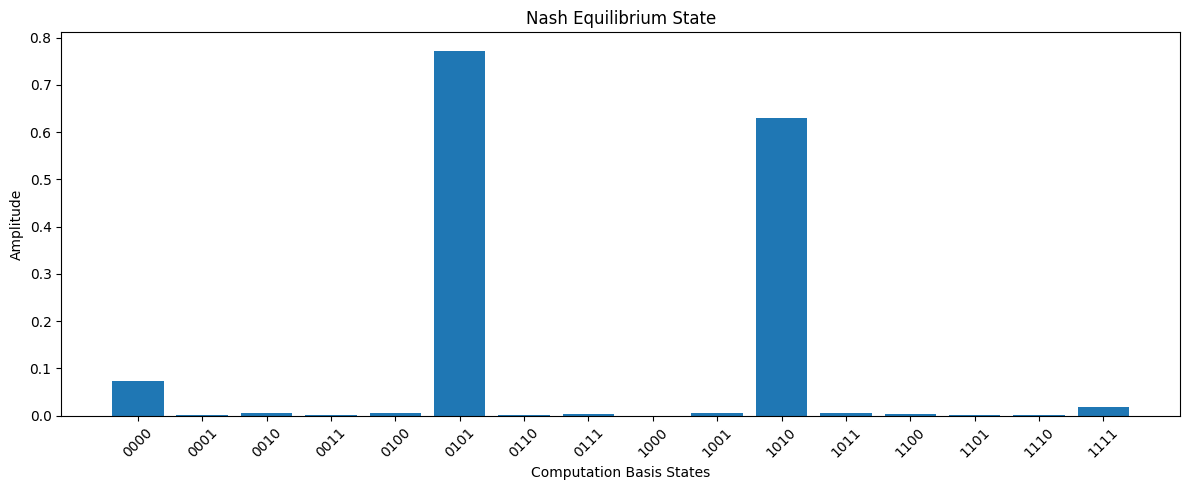


Computing exploitability with 10000 samples...


Computing exploitability for players: 100%|██████████| 4/4 [00:01<00:00,  2.85it/s]


Plotting exploitability vs angle...


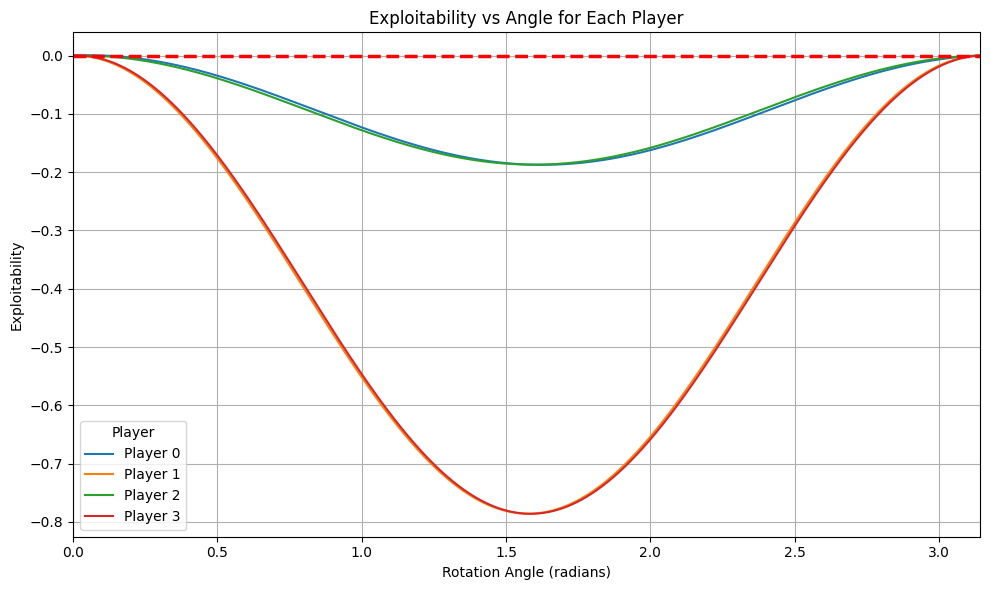


Nash Equilibrium Validation Results
Player 0: max exploitability = 0.000549 ✓
Player 1: max exploitability = 0.000036 ✓
Player 2: max exploitability = 0.000120 ✓
Player 3: max exploitability = 0.000162 ✓
Tolerance threshold: 0.001
Is Nash Equilibrium: True



{'state': array([7.39760910e-02, 2.49181635e-03, 6.74807509e-03, 2.10964099e-03,
        4.78362948e-03, 7.72544831e-01, 2.28800637e-03, 4.02882405e-03,
        4.03319112e-04, 5.82722316e-03, 6.30208234e-01, 5.50924291e-03,
        3.08672608e-03, 1.85674673e-03, 9.61844024e-04, 1.89917666e-02]),
 'exploitability': array([[ 0.00000000e+00,  6.35375199e-06,  1.26706083e-05, ...,
         -1.28181809e-05, -6.39064515e-06,  0.00000000e+00],
        [ 0.00000000e+00,  3.26706448e-06,  6.37897928e-06, ...,
         -6.99957281e-06, -3.42221288e-06,  0.00000000e+00],
        [ 0.00000000e+00,  2.95464385e-06,  5.87237251e-06, ...,
         -6.02002856e-06, -2.99155786e-06,  0.00000000e+00],
        [ 0.00000000e+00,  7.02146130e-06,  1.38877590e-05, ...,
         -1.45084023e-05, -7.17662215e-06,  0.00000000e+00]],
       shape=(4, 10000)),
 'max_exploitability': array([5.48693085e-04, 3.60343965e-05, 1.19647939e-04, 1.62361709e-04]),
 'is_nash': np.True_}

In [11]:
df.sort_values(by='welfare', ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)
print(df.head(10))
max_welfare_eq = np.abs(to_comp_basis(df.iloc[20]['state']))
compute_and_validate_nash_equilibrium(max_welfare_eq, H, num_samples=10000)


In [13]:
print(df.iloc[20]["welfare"])

10.008663476586007
